# Exploratory Data Analysis on Final Datasets

In [3]:
import os

import matplotlib.pyplot as plt
import pandas as pd
import pyarrow.parquet as pq
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [4]:
base_path = r"..\..\data\Final Datasets"

bookmeas_dataset = os.path.join(base_path, "merged_cleaned_balanced_15k.parquet")
materials_dataset = os.path.join(base_path, "filtered_materials_encoded_time_cut.parquet")

In [5]:
df_materials = pd.read_parquet(materials_dataset)
df_bo_me = pd.read_parquet(bookmeas_dataset)

In [6]:
df_materials.columns

Index(['component_position', 'component_id', 'serial_number_id', 'station_id',
       'supplier_id', 'mounting_place', 'panel_position', 'created_at',
       'book_state', 'container_number_freq'],
      dtype='object')

In [7]:
df_materials.shape

(926, 10)

In [8]:
df_materials.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 926 entries, 0 to 925
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype              
---  ------                 --------------  -----              
 0   component_position     926 non-null    object             
 1   component_id           926 non-null    object             
 2   serial_number_id       926 non-null    object             
 3   station_id             926 non-null    object             
 4   supplier_id            926 non-null    object             
 5   mounting_place         926 non-null    object             
 6   panel_position         926 non-null    object             
 7   created_at             926 non-null    datetime64[us, UTC]
 8   book_state             926 non-null    int32              
 9   container_number_freq  926 non-null    int64              
dtypes: datetime64[us, UTC](1), int32(1), int64(1), object(7)
memory usage: 68.9+ KB


In [9]:
df_materials.describe()

,book_state,container_number_freq
count,926.00000,926.000000
mean,0.50000,9350.363931
std,0.50027,7469.743764
min,0.00000,50.000000
25%,0.00000,3555.250000
50%,0.50000,7461.500000
75%,1.00000,13064.250000
max,1.00000,42711.000000


In [10]:
#df_materials.isnull().sum()
df_materials.nunique()

component_position       148
component_id             133
serial_number_id         484
station_id                 3
supplier_id               28
mounting_place           242
panel_position             2
created_at               469
book_state                 2
container_number_freq    423
dtype: int64

In [11]:
df_materials['book_state'].value_counts()

book_state
1    463
0    463
Name: count, dtype: int64

In [12]:
df_bo_me.columns

Index(['serial_number_id', 'station_id', 'book_state', 'created_at',
       'measure_step_number', 'measure_value', 'measurement_name_encoded',
       'measurement_unit_encoded', 'is_within_limits', 'booking_id',
       'workstep_number_mes', 'book_stamp', 'part_group'],
      dtype='object')

In [13]:
df_bo_me.shape

(30000, 13)

In [14]:
df_bo_me.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype              
---  ------                    --------------  -----              
 0   serial_number_id          30000 non-null  object             
 1   station_id                30000 non-null  object             
 2   book_state                30000 non-null  int32              
 3   created_at                30000 non-null  datetime64[us, UTC]
 4   measure_step_number       30000 non-null  int32              
 5   measure_value             30000 non-null  float64            
 6   measurement_name_encoded  30000 non-null  int64              
 7   measurement_unit_encoded  30000 non-null  int64              
 8   is_within_limits          30000 non-null  int32              
 9   booking_id                30000 non-null  object             
 10  workstep_number_mes       30000 non-null  int32              
 11  book_stamp     

In [15]:
'''import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(df_bo_me.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("nan")'''

'import seaborn as sns\nimport matplotlib.pyplot as plt\n\nplt.figure(figsize=(12,6))\nsns.heatmap(df_bo_me.isnull(), cbar=False, yticklabels=False, cmap=\'viridis\')\nplt.title("nan")'

In [16]:
df_bo_me.describe()

,book_state,measure_step_number,measure_value,measurement_name_encoded,measurement_unit_encoded,is_within_limits,workstep_number_mes
count,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000
mean,0.500000,458.931733,258.808010,41695.358800,6.587255e+06,0.987700,2.100167
std,0.500008,287.544836,378.541196,9582.237248,4.543912e+06,0.110223,0.556606
min,0.000000,0.000000,0.000000,2665.000000,4.183200e+04,0.000000,1.000000
25%,0.000000,205.000000,9.198977,41503.000000,3.775669e+06,1.000000,2.000000
50%,0.500000,457.000000,50.734350,41832.000000,5.022683e+06,1.000000,2.000000
75%,1.000000,708.000000,555.560500,41833.000000,1.302710e+07,1.000000,2.000000
max,1.000000,1024.000000,19800.000000,81352.000000,1.302710e+07,1.000000,5.000000


In [17]:
#df_bo_me.isnull().sum()
df_bo_me.nunique()

serial_number_id            13035
station_id                      6
book_state                      2
created_at                  23250
measure_step_number           996
measure_value               21875
measurement_name_encoded       20
measurement_unit_encoded       22
is_within_limits                2
booking_id                  13156
workstep_number_mes             3
book_stamp                  13154
part_group                      7
dtype: int64

In [18]:
for col in df_bo_me.columns:
    if df_bo_me[col].nunique() <= 100000:
        print(f"\n{col}:")
        print(df_bo_me[col].value_counts())


serial_number_id:
serial_number_id
c89a5b10    242
cce4d2f2    196
cd38585a    193
36854b86    190
952be494    181
           ... 
f07c4f50      1
4ba44623      1
c1545338      1
646f656f      1
5bf5eb34      1
Name: count, Length: 13035, dtype: int64

station_id:
station_id
1405e64b    13026
38b291ac     6056
464416bb     5071
0c3fb4ee     4652
2435c59b     1050
c61cc047      145
Name: count, dtype: int64

book_state:
book_state
1    15000
0    15000
Name: count, dtype: int64

created_at:
created_at
2025-03-28 09:42:15.267000+00:00    70
2025-03-28 10:43:04.158000+00:00    59
2025-05-09 11:50:23.664000+00:00    48
2025-05-09 12:38:01.995000+00:00     7
2025-03-05 19:06:19.840000+00:00     7
                                    ..
2025-04-22 07:59:01.304000+00:00     1
2025-05-08 19:00:13.553000+00:00     1
2025-03-05 11:21:28.098000+00:00     1
2025-03-19 05:15:43.174000+00:00     1
2025-04-17 00:38:41.228000+00:00     1
Name: count, Length: 23250, dtype: int64

measure_step_number:
m

In [19]:
df_bo_me['book_state'].value_counts()

book_state
1    15000
0    15000
Name: count, dtype: int64

In [18]:
'''quality_counts = df_bo_me['book_state'].value_counts() #both balanced
quality_counts = df_materials['book_state'].value_counts()

plt.figure(figsize=(8, 6))
plt.bar(quality_counts.index, quality_counts, color='darkblue')
plt.title('Count Plot of Quality')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.show()'''

"quality_counts = df_bo_me['book_state'].value_counts() #both balanced\nquality_counts = df_materials['book_state'].value_counts()\n\nplt.figure(figsize=(8, 6))\nplt.bar(quality_counts.index, quality_counts, color='darkblue')\nplt.title('Count Plot of Quality')\nplt.xlabel('Quality')\nplt.ylabel('Count')\nplt.show()"

<Axes: title={'center': 'Class Distribution (book_state)'}, xlabel='book_state'>

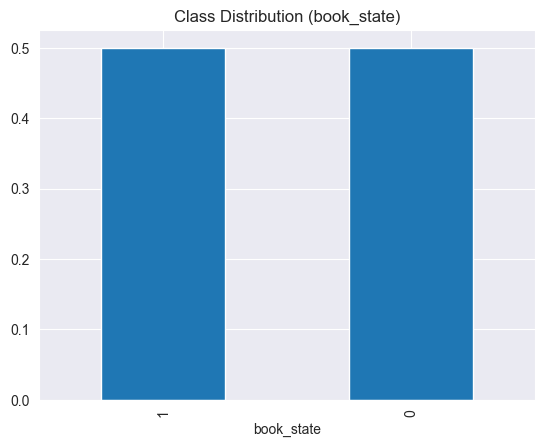

In [20]:
df_bo_me['book_state'].value_counts(normalize=True).plot(kind='bar', title='Class Distribution (book_state)')

In [21]:
df_bo_me.columns

Index(['serial_number_id', 'station_id', 'book_state', 'created_at',
       'measure_step_number', 'measure_value', 'measurement_name_encoded',
       'measurement_unit_encoded', 'is_within_limits', 'booking_id',
       'workstep_number_mes', 'book_stamp', 'part_group'],
      dtype='object')

In [22]:
df_bo_me.dtypes

serial_number_id                         object
station_id                               object
book_state                                int32
created_at                  datetime64[us, UTC]
measure_step_number                       int32
measure_value                           float64
measurement_name_encoded                  int64
measurement_unit_encoded                  int64
is_within_limits                          int32
booking_id                               object
workstep_number_mes                       int32
book_stamp                  datetime64[us, UTC]
part_group                               object
dtype: object

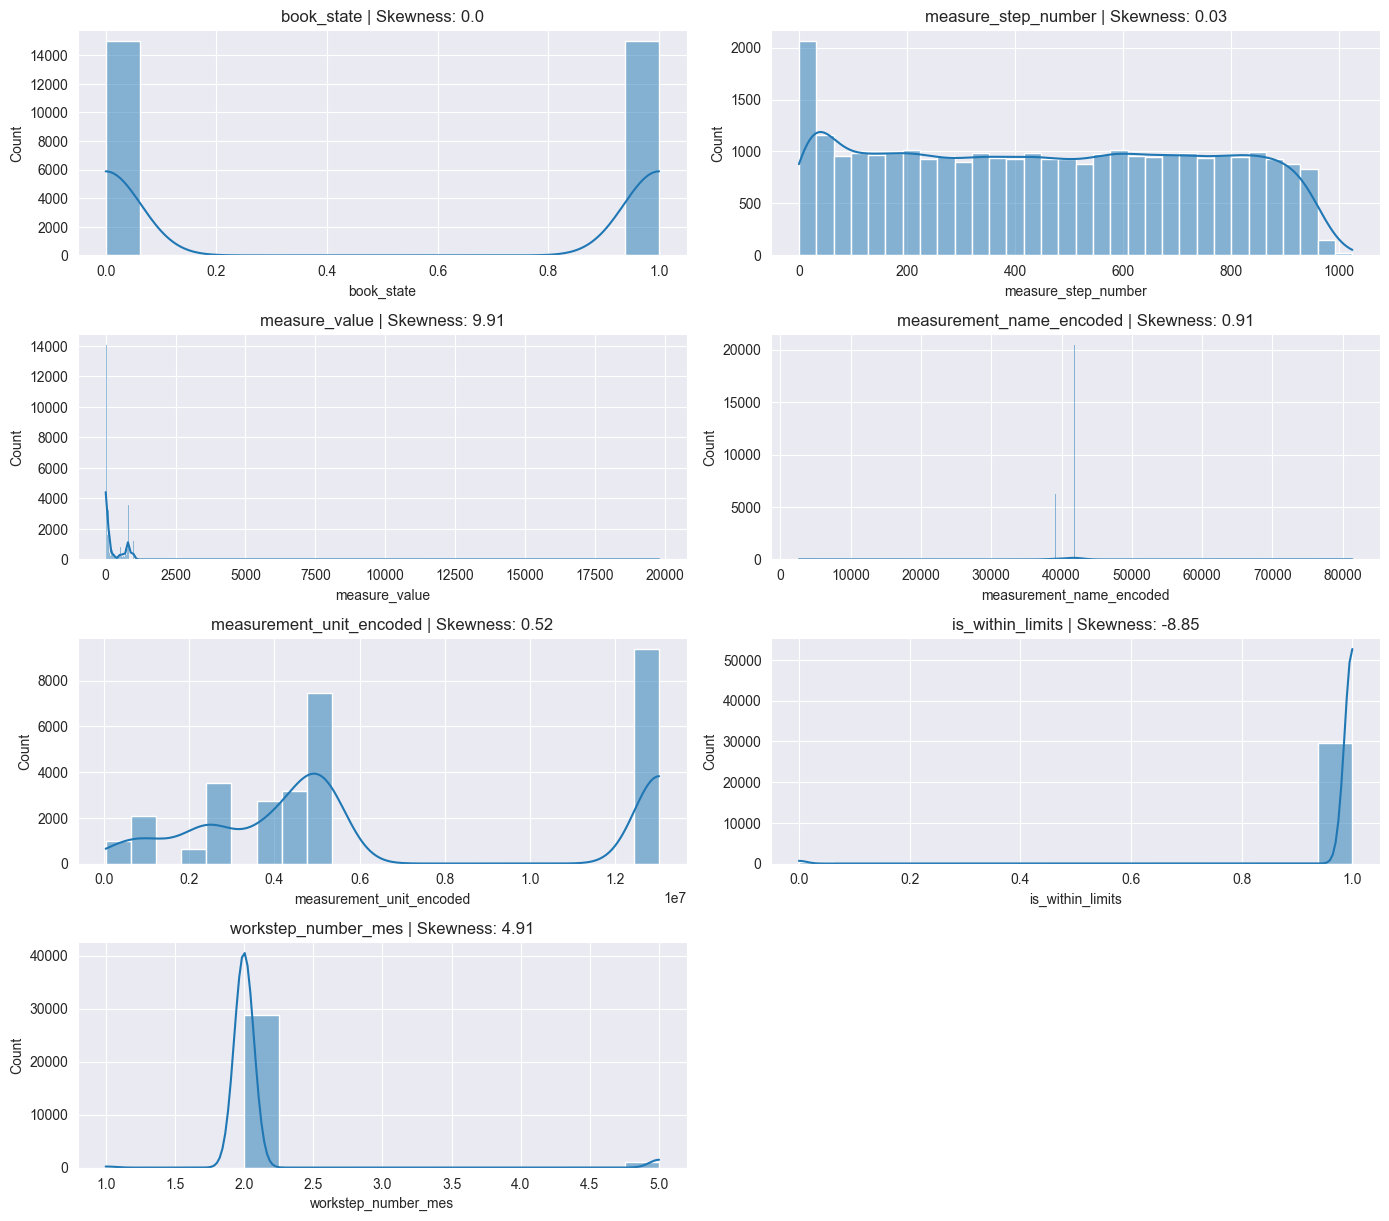

In [23]:
sns.set_style("darkgrid")

numerical_columns = df_bo_me.select_dtypes(include=["int32", "int64", "float64"]).columns

plt.figure(figsize=(14, len(numerical_columns) * 3))
for idx, feature in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 2, idx)
    sns.histplot(df_bo_me[feature], kde=True)
    plt.title(f"{feature} | Skewness: {round(df_bo_me[feature].skew(), 2)}")

plt.tight_layout()
plt.show()

In [23]:
'''plt.figure(figsize=(10, 8))

sns.swarmplot(x="station_id", y="measure_value", data=df_bo_me, palette='viridis')

plt.title('Swarm Plot for station id and book state')
plt.xlabel('station id')
plt.ylabel('book state')
plt.show()'''

'plt.figure(figsize=(10, 8))\n\nsns.swarmplot(x="station_id", y="measure_value", data=df_bo_me, palette=\'viridis\')\n\nplt.title(\'Swarm Plot for station id and book state\')\nplt.xlabel(\'station id\')\nplt.ylabel(\'book state\')\nplt.show()'

<Figure size 1000x600 with 0 Axes>

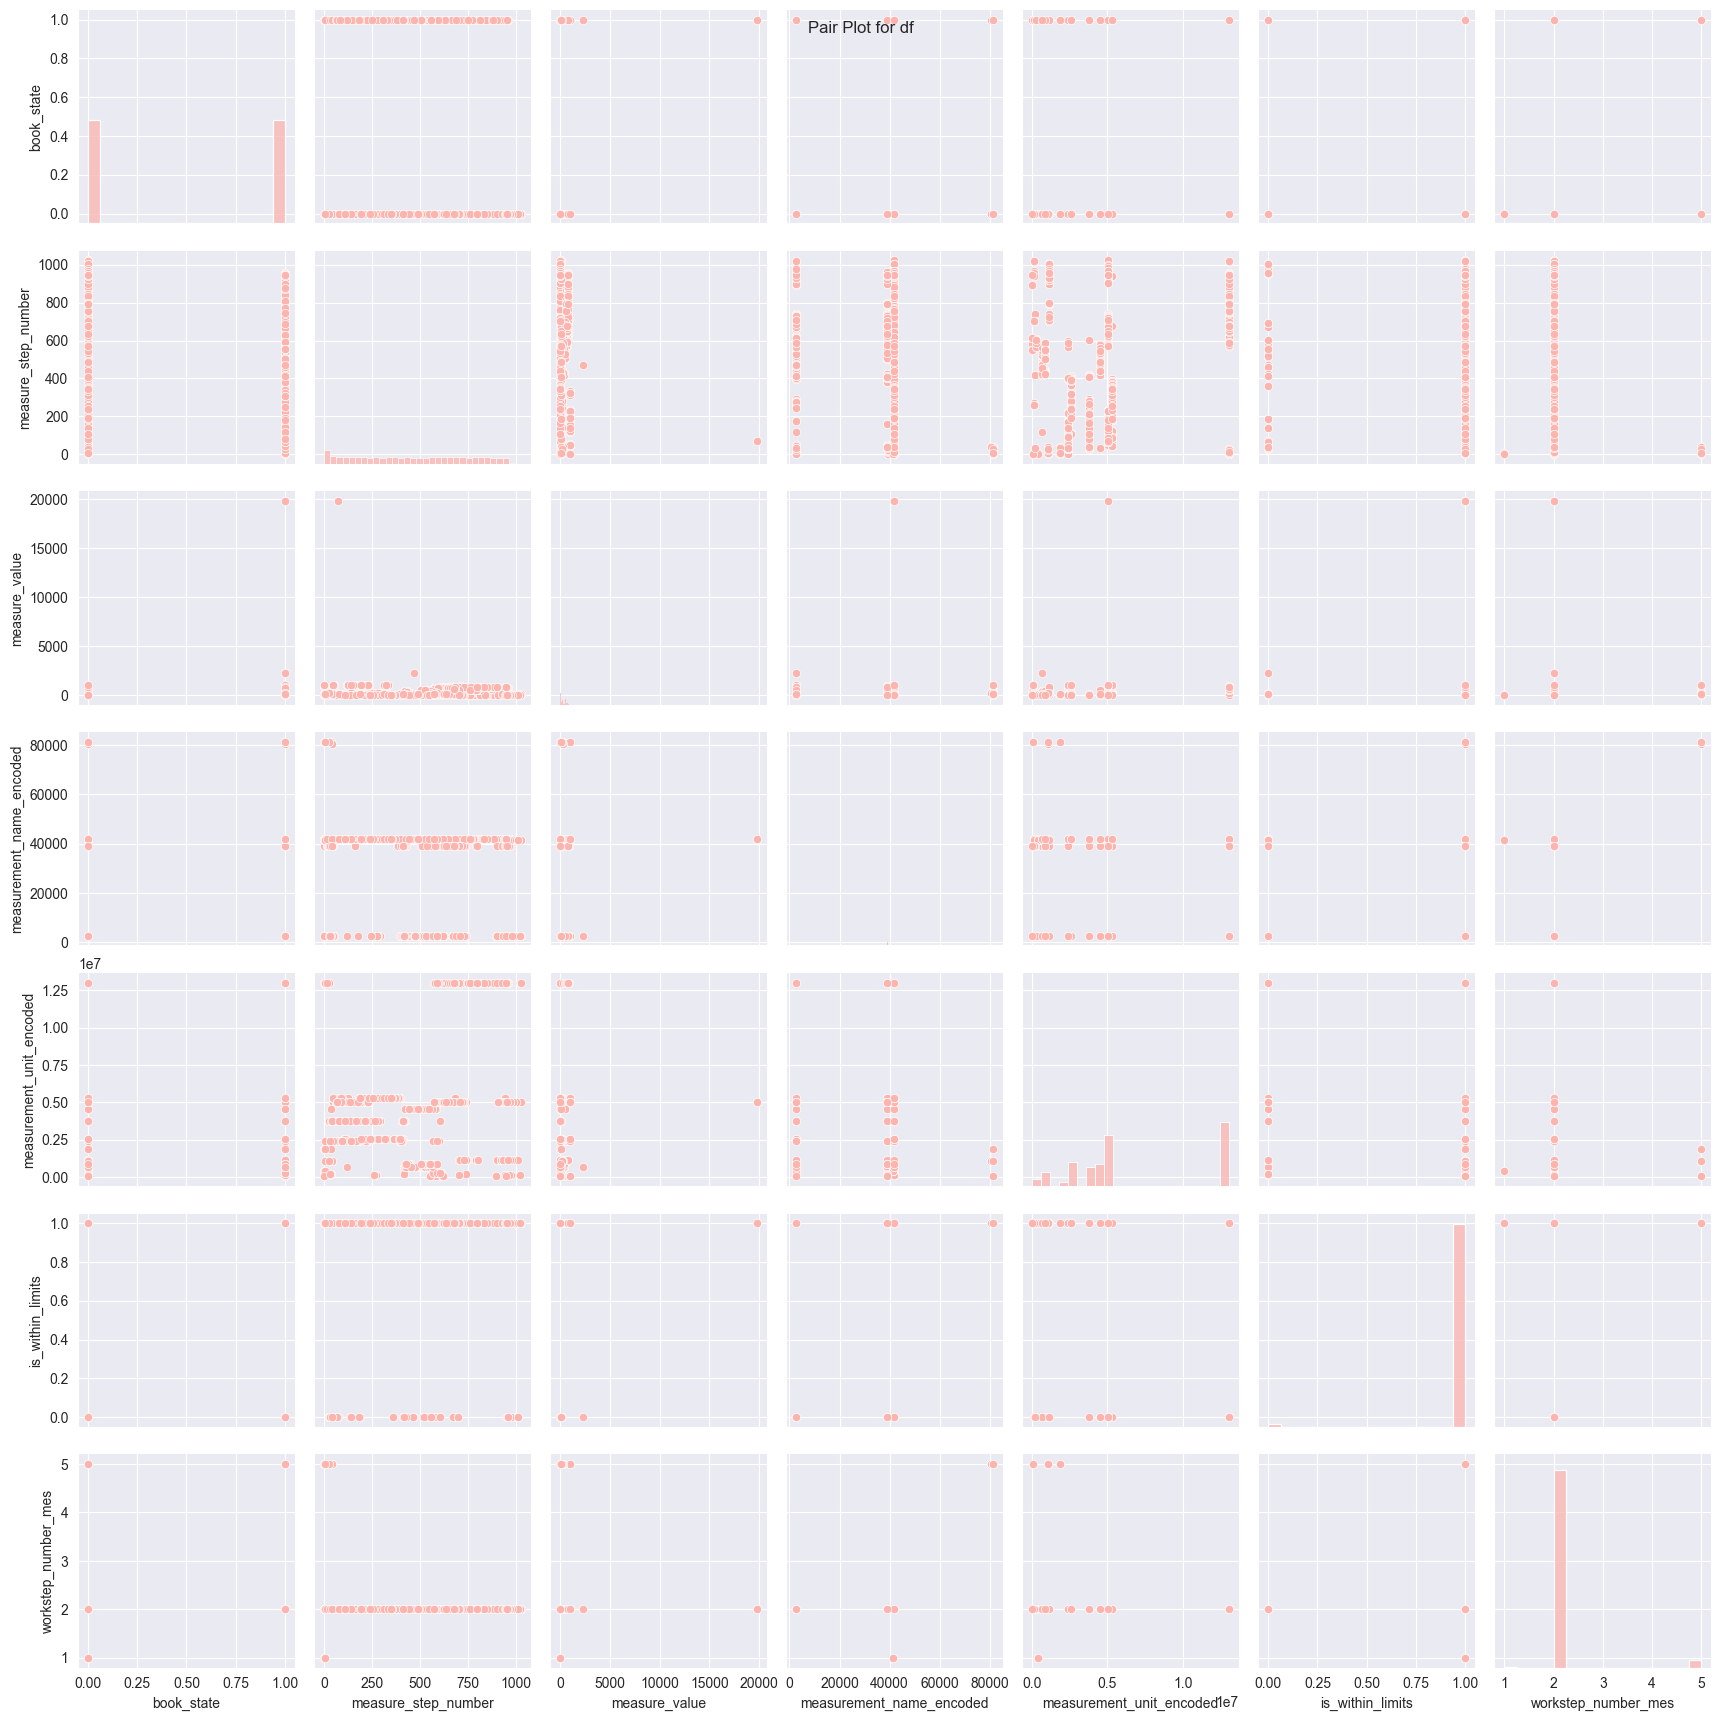

In [24]:
sns.set_palette("Pastel1")

plt.figure(figsize=(10, 6))

sns.pairplot(df_bo_me)

plt.suptitle('Pair Plot for df')
plt.show()

In [25]:
'''plt.figure(figsize=(15, 10))

sns.heatmap(df_bo_me.corr(), annot=True, fmt='.2f', cmap='Pastel2', linewidths=2)

plt.title('Correlation Heatmap')
plt.show()'''

"plt.figure(figsize=(15, 10))\n\nsns.heatmap(df_bo_me.corr(), annot=True, fmt='.2f', cmap='Pastel2', linewidths=2)\n\nplt.title('Correlation Heatmap')\nplt.show()"

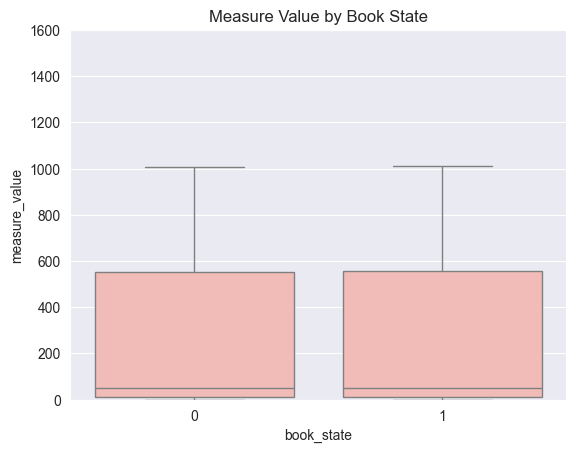

In [25]:
sns.boxplot(x='book_state', y='measure_value', data=df_bo_me)
plt.title("Measure Value by Book State")
plt.ylim(0, 1600)
plt.show()

Text(0.5, 1.0, 'Distribution of measure_step_number by book_state')

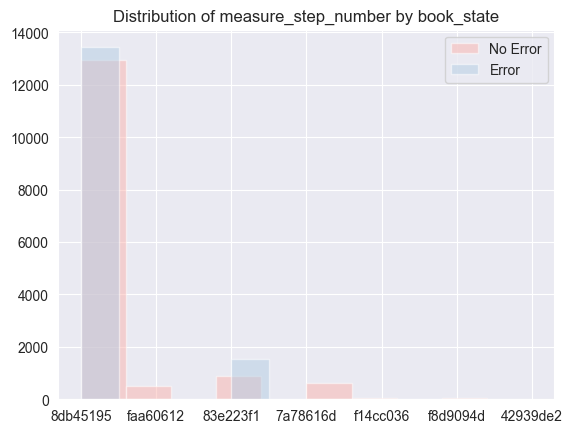

In [26]:
df_bo_me[df_bo_me['book_state'] == 0]['part_group'].hist(alpha=0.5, label='No Error')
df_bo_me[df_bo_me['book_state'] == 1]['part_group'].hist(alpha=0.5, label='Error')
plt.legend()
plt.title('Distribution of measure_step_number by book_state')

Text(0.5, 1.0, 'Distribution of measure_step_number by book_state')

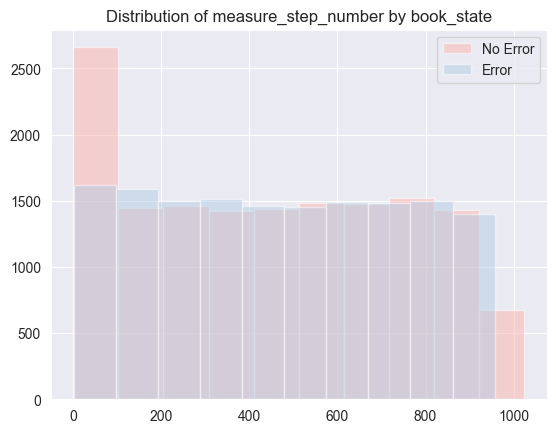

In [27]:
df_bo_me[df_bo_me['book_state'] == 0]['measure_step_number'].hist(alpha=0.5, label='No Error')
df_bo_me[df_bo_me['book_state'] == 1]['measure_step_number'].hist(alpha=0.5, label='Error')
plt.legend()
plt.title('Distribution of measure_step_number by book_state')

Text(0.5, 1.0, 'Error Rate by Station')

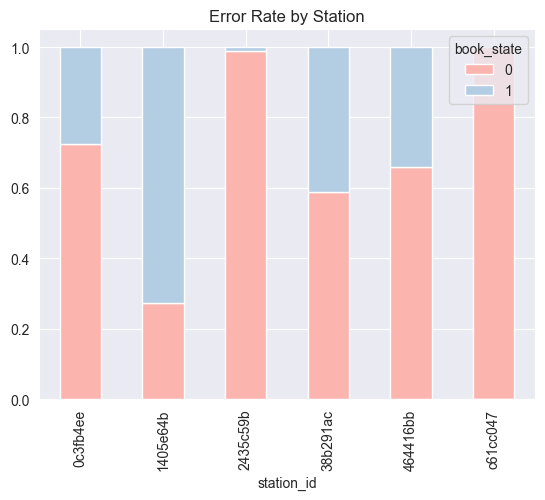

In [28]:
pd.crosstab(df_bo_me['station_id'], df_bo_me['book_state'], normalize='index').plot(kind='bar', stacked=True)
plt.title('Error Rate by Station')

In [30]:
#pd.crosstab(df_bo_me['serial_number_id'], df_bo_me['book_state'], normalize='index').plot(kind='bar', stacked=True)
#plt.title('Error Rate by Serial Number')
#length 13000

In [31]:
#pd.crosstab(df_bo_me['booking_id'], df_bo_me['book_state'], normalize='index').plot(kind='bar', stacked=True)
#plt.title('Error Rate by Serial Number')
#length 13000

Text(0.5, 1.0, 'Correlation Matrix')

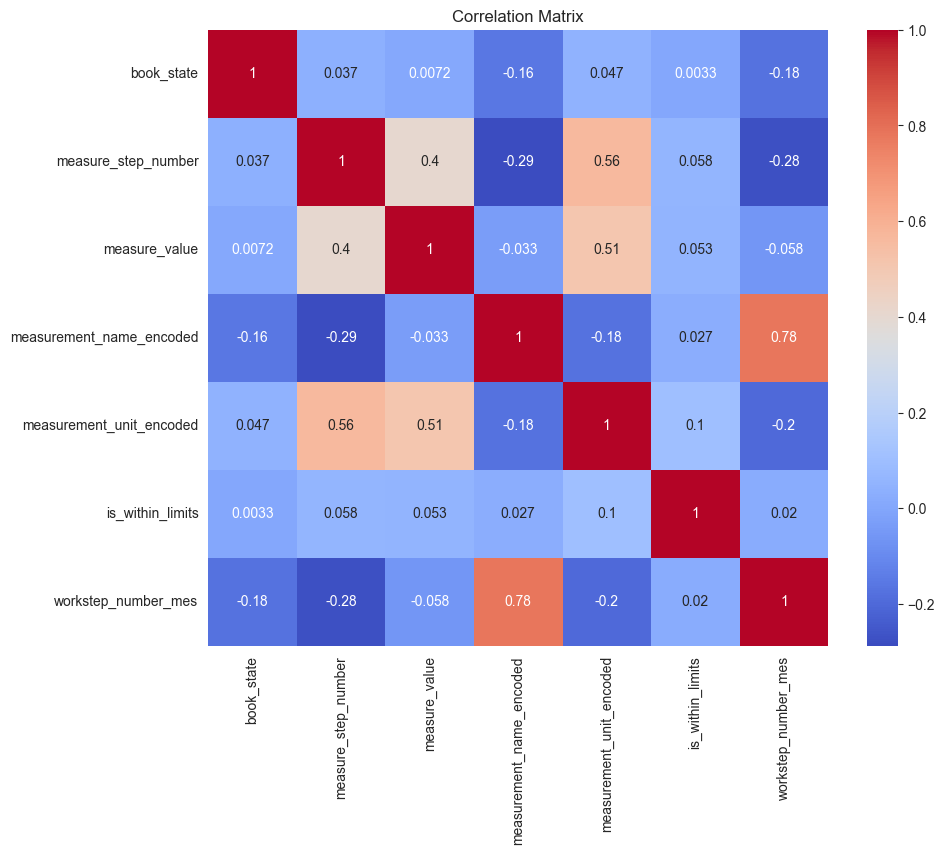

In [29]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_bo_me.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")

Text(0.5, 1.0, 'Daily Error Rate Over Time')

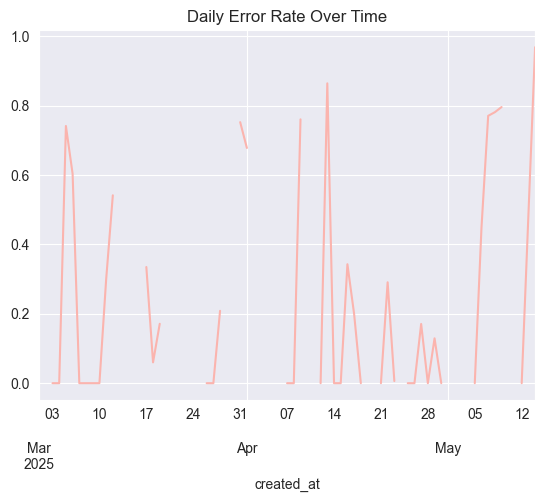

In [30]:
df_bo_me['created_at'] = pd.to_datetime(df_bo_me['created_at'])
df_bo_me.set_index('created_at').resample('D')['book_state'].mean().plot()
plt.title('Daily Error Rate Over Time')

In [31]:
error_rate_per_station = df_bo_me.groupby('station_id')['book_state'].mean()

# Merge
df_bo_me['station_error_rate'] = df_bo_me['station_id'].map(error_rate_per_station)

In [32]:
df_bo_me['book_lag_seconds'] = (df_bo_me['created_at'] - df_bo_me['book_stamp']).dt.total_seconds()

Text(0.5, 1.0, 'Station Error Rate vs Book State')

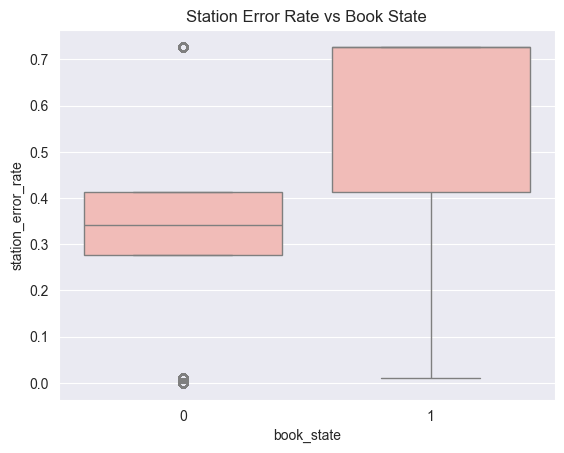

In [33]:
sns.boxplot(x='book_state', y='station_error_rate', data=df_bo_me)
plt.title("Station Error Rate vs Book State")
#Haben fehlerhafte Teile höhere Station-Fehlerrate

In [34]:
station_ranking = df_bo_me.groupby('station_id')['book_state'].mean().sort_values(ascending=False)
print(station_ranking)  #höchste Fehlerquote

station_id
1405e64b    0.727238
38b291ac    0.412979
464416bb    0.341550
0c3fb4ee    0.275580
2435c59b    0.011429
c61cc047    0.000000
Name: book_state, dtype: float64


Text(0.5, 1.0, 'Distribution of Station Error Rate by Book State')

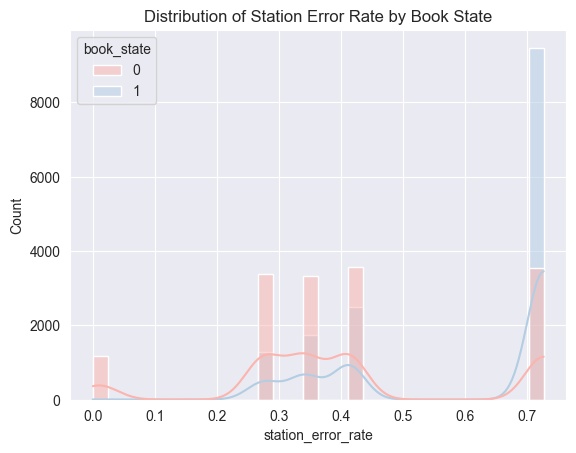

In [35]:
sns.histplot(data=df_bo_me, x='station_error_rate', hue='book_state', kde=True, bins=30)
plt.title("Distribution of Station Error Rate by Book State")

Text(0.5, 1.0, 'Distribution of Booking Lag (Seconds)')

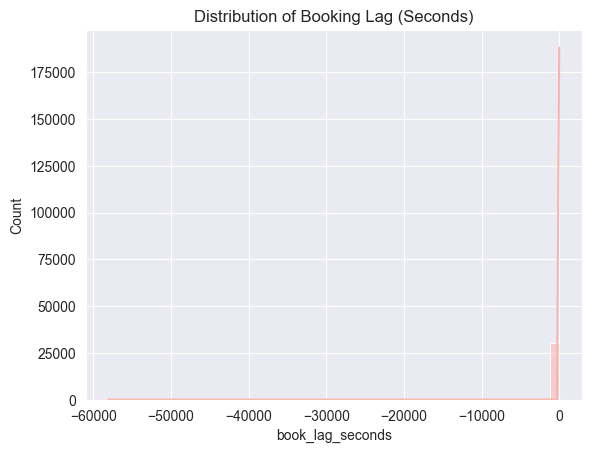

In [36]:
sns.histplot(df_bo_me['book_lag_seconds'], bins=50, kde=True)
plt.title("Distribution of Booking Lag (Seconds)")

Text(0.5, 1.0, 'Booking Lag by Book State')

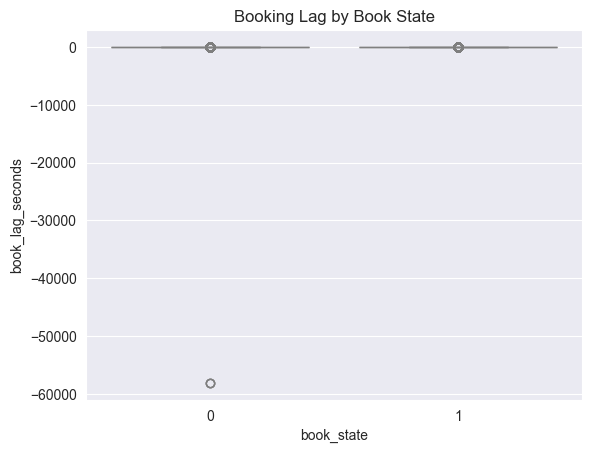

In [37]:
sns.boxplot(x='book_state', y='book_lag_seconds', data=df_bo_me)
plt.title("Booking Lag by Book State")

In [38]:
print(df_bo_me.groupby('book_state')['book_lag_seconds'].describe())  #Sind Extremwerte häufiger bei Fehlerteilen

              count       mean         std        min    25%    50%    75%  \
book_state                                                                   
0           15000.0 -11.498104  820.772553 -58070.201  0.089  0.109  0.134   
1           15000.0  -0.106396    0.197052     -3.375 -0.095 -0.075 -0.061   

              max  
book_state         
0           0.430  
1           0.016  


In [39]:
df_bo_me[df_bo_me['book_lag_seconds'] > 3600].groupby('station_id').size().sort_values(
    ascending=False)  #über 1 Stunde Verzögerung

Series([], dtype: int64)

<Axes: xlabel='book_state', ylabel='measure_step_number'>

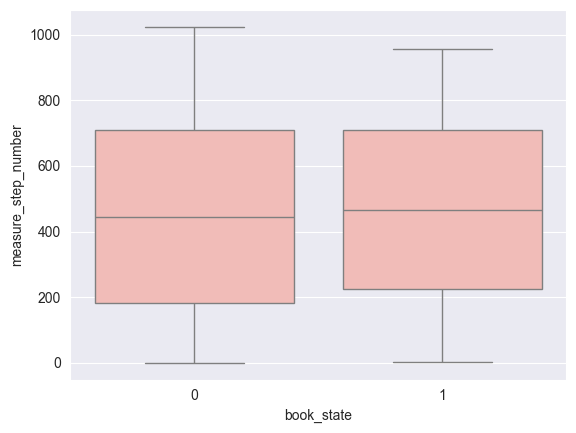

In [40]:
sns.boxplot(x='book_state', y='measure_step_number', data=df_bo_me)

<Axes: xlabel='book_lag_seconds', ylabel='Count'>

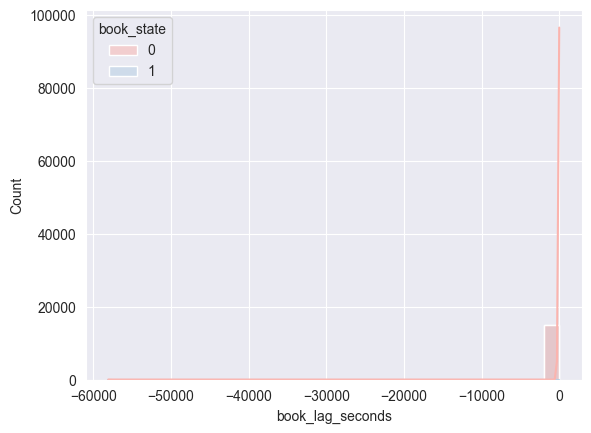

In [41]:
sns.histplot(data=df_bo_me, x='book_lag_seconds', hue='book_state', bins=30, kde=True)

<Axes: xlabel='book_stamp'>

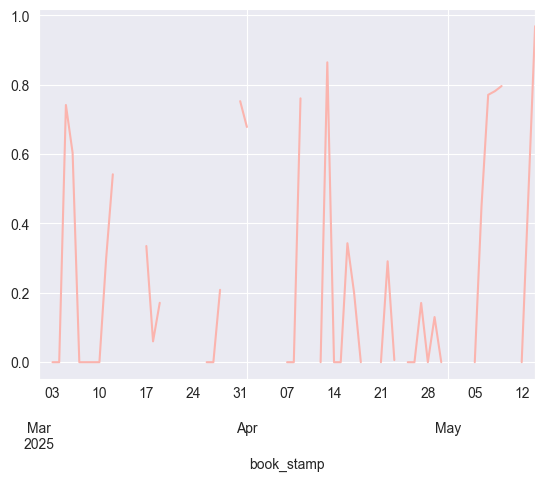

In [42]:
df_bo_me.set_index('book_stamp').resample('D')['book_state'].mean().plot()

<Axes: xlabel='station_error_rate', ylabel='book_lag_seconds'>

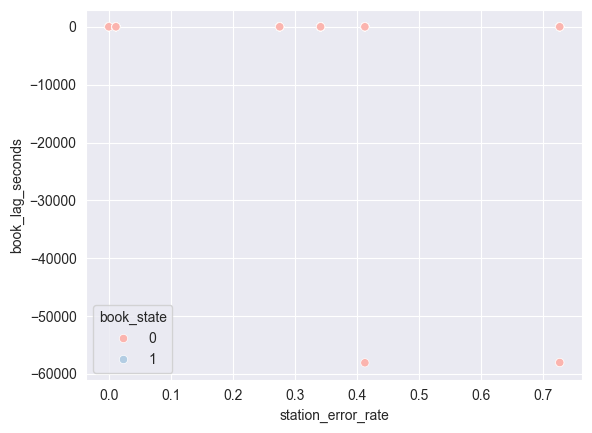

In [43]:
sns.scatterplot(data=df_bo_me, x='station_error_rate', y='book_lag_seconds', hue='book_state')
